# Baseline Implementation

Baseline for implementing Pearson correlation on SMA dataset.

## Imports and Dataset

In [1]:
import os
import scanpy as sc
import squidpy as sq
import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

sc.settings.verbosity = 2
sc.settings.set_figure_params(dpi=100, frameon=False)

/opt/anaconda3/envs/multi-omics/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/opt/anaconda3/envs/multi-omics/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


In [ ]:
# NOTE: Update THIS PATH to your extracted magpie_inputs/ directory
DATA_DIR = "../magpie_inputs"

# Dataset metadata
DATASETS = {
    'sma_vicari_brain': {
        'description': "PD model (6-OHDA mouse brain + human brain)",
        'modality': "Visium + MALDI-MSI (same section)",
        'samples': [
            'mouse_V11L12-038_B1', 'mouse_V11L12-038_D1', 'mouse_V11T16-085_C1',
            'human_V11T17-102_A1', 'human_V11T17-102_B1', 'human_V11T17-102_D1',
        ],
    },
    'bleo_mouse_lung': {
        'description': "Pulmonary fibrosis (bleomycin mouse lung)",
        'modality': "Visium + DESI-MSI (consecutive sections)",
        'samples': [
            'bleo_d21_1', 'bleo_d21_2', 'bleo_d21_3',
            'bleo_d21_4b', 'bleo_d21_5b', 'bleo_d21_6b',
            'control_d21_1', 'control_d21_3',
        ],
    },
    'desium_godfrey_breast': {
        'description': "Human breast cancer (invasive lobular carcinoma)",
        'modality': "Visium CytAssist + DESI-MSI (same section)",
        'samples': ['BC_1_515', 'BC_1_525', 'BC_2_515'],
    },
}

# Verify the data is present
print(f"Checking data at {DATA_DIR}")
for ds_name, info in DATASETS.items():
    ds_path = os.path.join(DATA_DIR, ds_name)
    n_found = sum(os.path.exists(os.path.join(ds_path, s)) for s in info['samples'])
    print(f"  {ds_name}: {n_found}/{len(info['samples'])} samples found — {info['description']}")

Checking data at ../magpie_inputs
  sma_vicari_brain: 6/6 samples found — PD model (6-OHDA mouse brain + human brain)
  bleo_mouse_lung: 8/8 samples found — Pulmonary fibrosis (bleomycin mouse lung)
  desium_godfrey_breast: 3/3 samples found — Human breast cancer (invasive lobular carcinoma)


## Baseline 3 Implementation

In [ ]:
# Utility Functions
import os
import numpy as np
import pandas as pd
import scanpy as sc
from scipy.stats import t
from statsmodels.stats.multitest import multipletests

def normalize_mz_labels(columns, decimals=4):
    """
    Convert MSI column labels like:
      'mz.130.05041' -> '130.0504'   (if decimals=4)
      '130.05041'    -> '130.0504'
    Returns a pandas Index of normalized string labels.
    """
    normalized = []

    for c in columns:
        s = str(c).strip()

        # Remove leading 'mz.' if present
        if s.startswith("mz."):
            s = s[3:]

        mz_val = float(s)
        normalized.append(f"{mz_val:.{decimals}f}")

    return pd.Index(normalized)

def load_visium_gene_names(dataset_name, sample):
    visium_path = os.path.join(DATA_DIR, dataset_name, sample, "visium")
    adata = sc.read_visium(visium_path)
    adata.var_names_make_unique()
    return pd.Index(adata.var_names)

def load_msi_columns(dataset_name, sample):
    msi_path = os.path.join(DATA_DIR, dataset_name, sample, "msi", "MSI_intensities.csv")
    msi = pd.read_csv(msi_path, index_col=0)
    return pd.Index(msi.columns)

def find_common_genes(dataset_name, samples):
    gene_sets = []
    for sample in samples:
        genes = load_visium_gene_names(dataset_name, sample)
        gene_sets.append(set(genes))
    common_genes = sorted(set.intersection(*gene_sets))
    return common_genes

def find_common_mz(dataset_name, samples, decimals):
    mz_sets = []

    for sample in samples:
        raw_cols = load_msi_columns(dataset_name, sample)
        mz_norm = normalize_mz_labels(raw_cols, decimals=decimals)
        mz_sets.append(set(mz_norm))

    common_mz = sorted(set.intersection(*mz_sets), key=float)
    return common_mz

def choose_mz_precision(dataset_name, samples, decimals_to_try):
    """
    Try multiple rounding precisions and return the first one that yields
    a non-empty common m/z intersection across all samples.
    """
    for d in decimals_to_try:
        common_mz = find_common_mz(dataset_name, samples, decimals=d)
        print(f"decimals={d}: common m/z = {len(common_mz)}")
        if len(common_mz) > 0:
            return d, common_mz

    raise ValueError(
        "No common m/z features found across samples at any tested precision. "
        "You may need explicit m/z binning rather than strict rounded matching."
    )

def compute_sample_means(dataset_name, samples, common_genes, common_mz, mz_decimals):
    """
    Returns:
      X: samples x genes
      Y: samples x m/z
      sample_names
    """
    visium_means = []
    msi_means = []
    sample_names = []

    for sample in samples:
        print(f"\nProcessing {sample}...")

        # Load Visium
        visium_path = os.path.join(DATA_DIR, dataset_name, sample, "visium")
        adata = sc.read_visium(visium_path)
        adata.var_names_make_unique()

        visium_mean_series = pd.Series(
            np.asarray(adata.X.mean(axis=0)).ravel(),
            index=adata.var_names
        )

        # Reorder/subset to common genes
        visium_mean = visium_mean_series.loc[common_genes].to_numpy()

        # Load MSI
        msi_path = os.path.join(DATA_DIR, dataset_name, sample, "msi", "MSI_intensities.csv")
        msi = pd.read_csv(msi_path, index_col=0)

        # Normalize m/z labels
        msi.columns = normalize_mz_labels(msi.columns, decimals=mz_decimals)

        # If normalization creates duplicate m/z labels, merge them by averaging
        if msi.columns.duplicated().any():
            msi = msi.T.groupby(level=0).mean().T

        # Reorder/subset to common m/z
        missing_mz = set(common_mz) - set(msi.columns)
        if missing_mz:
            raise ValueError(
                f"After normalization, sample {sample} is missing "
                f"{len(missing_mz)} expected common m/z features."
            )

        msi_mean = msi.loc[:, common_mz].mean(axis=0).to_numpy()

        visium_means.append(visium_mean)
        msi_means.append(msi_mean)
        sample_names.append(sample)

        print(f"  Visium shape: {adata.shape}")
        print(f"  MSI shape: {msi.shape}")
        print(f"  Common genes retained: {len(common_genes)}")
        print(f"  Common m/z retained: {len(common_mz)}")

    X = np.vstack(visium_means)  # samples x genes
    Y = np.vstack(msi_means)     # samples x m/z

    return X, Y, sample_names

def compute_correlations(X, Y, gene_names, mz_names):
    """
    Compute Pearson correlation across samples between each gene and each m/z.
    Returns:
      corr_df, pval_df, qval_df, filtered_genes, filtered_mz
    """
    n_samples = X.shape[0]

    if n_samples < 3:
        raise ValueError("Need at least 3 samples for Pearson correlation.")

    # Remove zero-variance features across samples
    X_std = X.std(axis=0, ddof=1)
    Y_std = Y.std(axis=0, ddof=1)

    keep_genes = X_std > 0
    keep_mz = Y_std > 0

    Xf = X[:, keep_genes]
    Yf = Y[:, keep_mz]

    filtered_genes = np.array(gene_names)[keep_genes]
    filtered_mz = np.array(mz_names)[keep_mz]

    if Xf.shape[1] == 0:
        raise ValueError("No variable genes remain across samples.")

    if Yf.shape[1] == 0:
        raise ValueError("No variable m/z features remain across samples.")

    print("\nAfter removing zero-variance features:")
    print(f"  Genes kept: {Xf.shape[1]} / {X.shape[1]}")
    print(f"  m/z kept:   {Yf.shape[1]} / {Y.shape[1]}")

    # Z-score across samples
    Xz = (Xf - Xf.mean(axis=0)) / Xf.std(axis=0, ddof=1)
    Yz = (Yf - Yf.mean(axis=0)) / Yf.std(axis=0, ddof=1)

    # Pearson correlation matrix
    correlations = (Xz.T @ Yz) / (n_samples - 1)

    corr_df = pd.DataFrame(
        correlations,
        index=filtered_genes,
        columns=filtered_mz
    )

    # P-values from correlation coefficients
    df = n_samples - 2
    r_clip = np.clip(correlations, -0.999999999, 0.999999999)
    t_stat = r_clip * np.sqrt(df / (1 - r_clip**2))
    pvalues = 2 * t.sf(np.abs(t_stat), df=df)

    pval_df = pd.DataFrame(
        pvalues,
        index=filtered_genes,
        columns=filtered_mz
    )

    # FDR correction
    p_flat = pvalues.ravel()
    valid = np.isfinite(p_flat)

    q_flat = np.full_like(p_flat, np.nan, dtype=float)
    q_flat[valid] = multipletests(p_flat[valid], method="fdr_bh")[1]

    qvalues = q_flat.reshape(pvalues.shape)

    qval_df = pd.DataFrame(
        qvalues,
        index=filtered_genes,
        columns=filtered_mz
    )

    return corr_df, pval_df, qval_df, filtered_genes, filtered_mz

def extract_top_pairs(corr_df, pval_df, qval_df, top_k=20):
    corr = corr_df.to_numpy()
    pval = pval_df.to_numpy()
    qval = qval_df.to_numpy()

    flat_idx = np.argsort(-np.abs(corr).ravel())[:top_k]
    top_i, top_j = np.unravel_index(flat_idx, corr.shape)

    top_results_df = pd.DataFrame({
        "gene": corr_df.index.to_numpy()[top_i],
        "mz": corr_df.columns.to_numpy()[top_j],
        "correlation": corr[top_i, top_j],
        "pvalue": pval[top_i, top_j],
        "qvalue": qval[top_i, top_j]
    })

    return top_results_df

### Running on SMA dataset

Vectorized Pearson correlation

In [ ]:
# Configuration
dataset_name = "sma_vicari_brain"
samples = DATASETS[dataset_name]["samples"]
top_k = 20

# Try these m/z rounding precisions from strict to coarse
mz_decimals_to_try = [5, 4, 3, 2, 1]

print(f"Running sample-level mean correlation on dataset: {dataset_name}")
print(f"Number of samples: {len(samples)}")

# Main workflow
print("\nFinding common genes across all samples...")
common_genes = find_common_genes(dataset_name, samples)
print(f"Common genes: {len(common_genes)}")

if len(common_genes) == 0:
    raise ValueError("No common genes found across samples.")

print("\nFinding common m/z across all samples...")
mz_decimals, common_mz = choose_mz_precision(
    dataset_name=dataset_name,
    samples=samples,
    decimals_to_try=mz_decimals_to_try
)

print(f"\nSelected m/z rounding precision: {mz_decimals}")
print(f"Common m/z features: {len(common_mz)}")

X, Y, sample_names = compute_sample_means(
    dataset_name=dataset_name,
    samples=samples,
    common_genes=common_genes,
    common_mz=common_mz,
    mz_decimals=mz_decimals
)

print("\nFinal matrix shapes:")
print(f"  X (samples x genes): {X.shape}")
print(f"  Y (samples x m/z):   {Y.shape}")

corr_df, pval_df, qval_df, filtered_genes, filtered_mz = compute_correlations(
    X=X,
    Y=Y,
    gene_names=common_genes,
    mz_names=common_mz
)

top_results_df = extract_top_pairs(
    corr_df=corr_df,
    pval_df=pval_df,
    qval_df=qval_df,
    top_k=top_k
)

print("\nTop correlated gene-m/z pairs:")
print(top_results_df)

results = {
    "dataset_name": dataset_name,
    "samples": sample_names,
    "mz_decimals": mz_decimals,
    "common_genes": common_genes,
    "common_mz": common_mz,
    "filtered_genes": filtered_genes,
    "filtered_mz": filtered_mz,
    "visium_means": X,
    "msi_means": Y,
    "corr_df": corr_df,
    "pval_df": pval_df,
    "qval_df": qval_df,
    "top_results_df": top_results_df,
}

Running sample-level mean correlation on dataset: sma_vicari_brain
Number of samples: 6

Finding common genes across all samples...
reading ../magpie_inputs/sma_vicari_brain/mouse_V11L12-038_B1/visium/filtered_feature_bc_matrix.h5
 (0:00:00)
reading ../magpie_inputs/sma_vicari_brain/mouse_V11L12-038_D1/visium/filtered_feature_bc_matrix.h5
 (0:00:00)
reading ../magpie_inputs/sma_vicari_brain/mouse_V11T16-085_C1/visium/filtered_feature_bc_matrix.h5
 (0:00:00)
reading ../magpie_inputs/sma_vicari_brain/human_V11T17-102_A1/visium/filtered_feature_bc_matrix.h5
 (0:00:00)
reading ../magpie_inputs/sma_vicari_brain/human_V11T17-102_B1/visium/filtered_feature_bc_matrix.h5
 (0:00:00)
reading ../magpie_inputs/sma_vicari_brain/human_V11T17-102_D1/visium/filtered_feature_bc_matrix.h5
 (0:00:00)
Common genes: 18

Finding common m/z across all samples...
decimals=5: common m/z = 0
decimals=4: common m/z = 0
decimals=3: common m/z = 0
decimals=2: common m/z = 5

Selected m/z rounding precision: 2
Commo

## Baseline Results

In [ ]:
# Correlation Matrix for Genes of Interest
genes_of_interest = ["C9", "C3", "C2", "F7", "F8", "F9", "F10", "F12", "C9orf72"]
genes_present = [g for g in genes_of_interest if g in filtered_genes]

gene_idx = [list(filtered_genes).index(g) for g in genes_present]
gene_mat = X[:, gene_idx]

gene_corr = pd.DataFrame(
    np.corrcoef(gene_mat, rowvar=False),
    index=genes_present,
    columns=genes_present
)

print(gene_corr)

               C9        C3        C2        F7        F8        F9       F10  \
C9       1.000000 -0.518366  0.268829 -0.592137  0.348994 -0.417774 -0.127365   
C3      -0.518366  1.000000 -0.810062 -0.189076 -0.752747 -0.087344 -0.337355   
C2       0.268829 -0.810062  1.000000  0.359839  0.960178  0.380346  0.756716   
F7      -0.592137 -0.189076  0.359839  1.000000  0.249963  0.282285  0.502873   
F8       0.348994 -0.752747  0.960178  0.249963  1.000000  0.477628  0.832248   
F9      -0.417774 -0.087344  0.380346  0.282285  0.477628  1.000000  0.727622   
F10     -0.127365 -0.337355  0.756716  0.502873  0.832248  0.727622  1.000000   
F12      0.075291 -0.688458  0.962016  0.462506  0.956928  0.595246  0.892126   
C9orf72  0.131945 -0.726418  0.981268  0.464396  0.962542  0.507062  0.862048   

              F12   C9orf72  
C9       0.075291  0.131945  
C3      -0.688458 -0.726418  
C2       0.962016  0.981268  
F7       0.462506  0.464396  
F8       0.956928  0.962542  
F9       

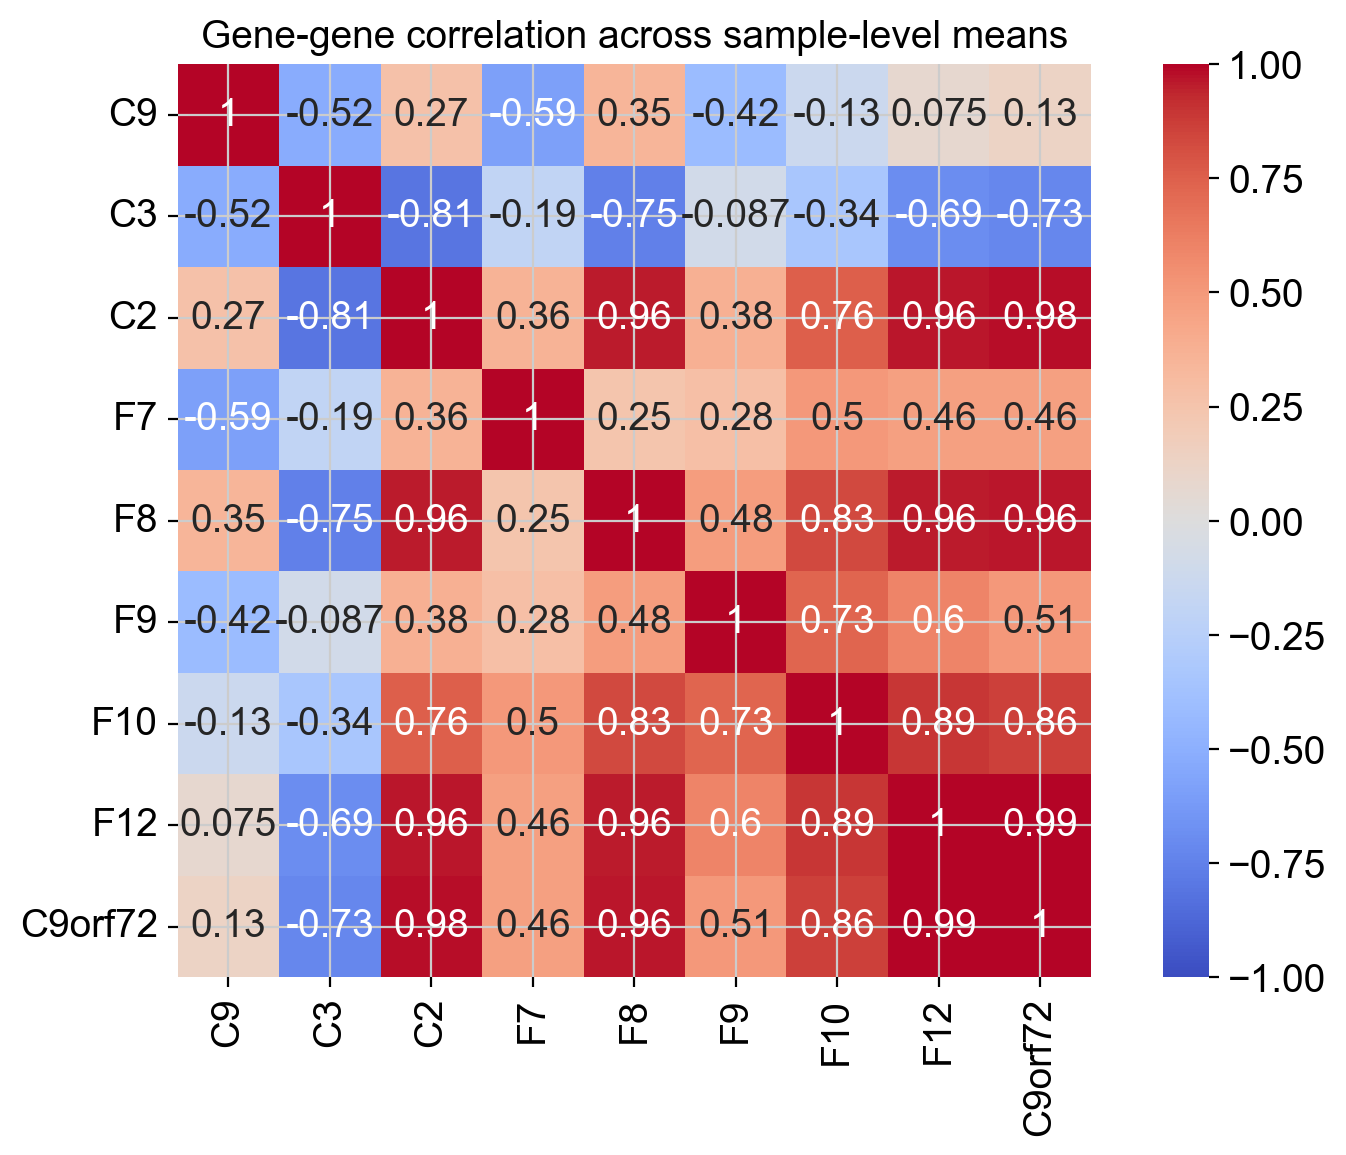

In [ ]:
# Gene-gene correlation heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(gene_corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Gene-gene correlation across sample-level means")
plt.tight_layout()
plt.show()

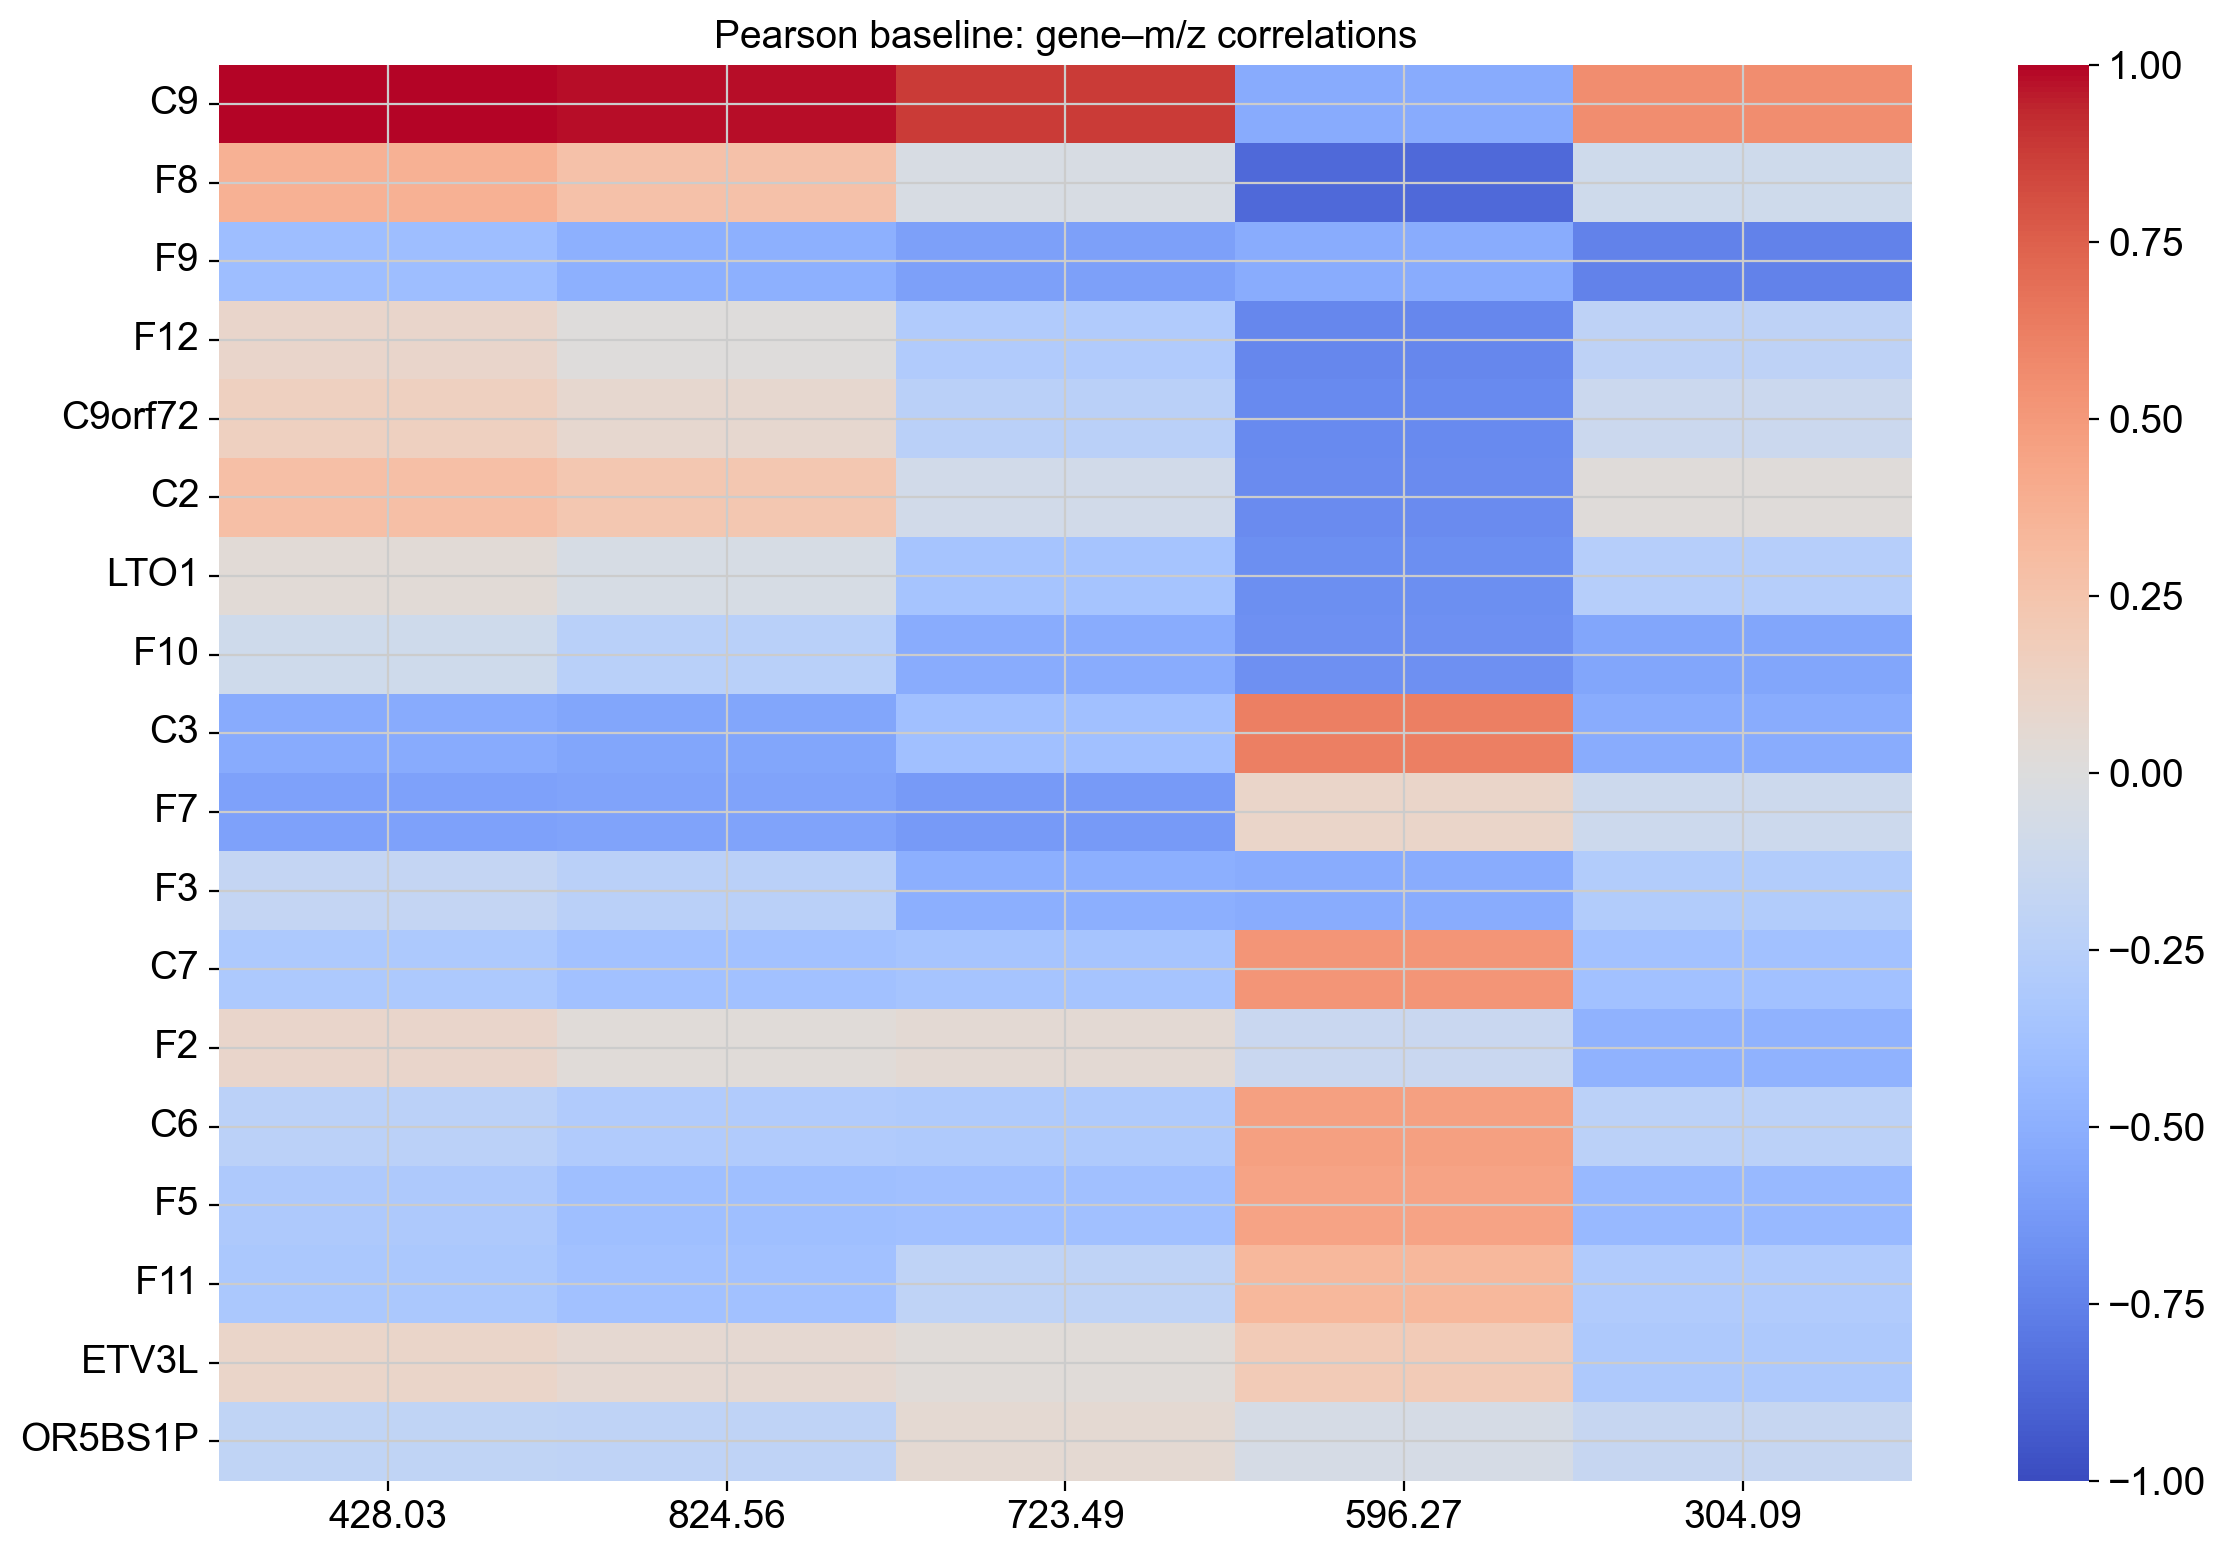

In [ ]:
# Heatmap of top gene-m/z correlations
import seaborn as sns
import matplotlib.pyplot as plt

max_gene = corr_df.abs().max(axis=1).sort_values(ascending=False).head(30).index
max_mz = corr_df.abs().max(axis=0).sort_values(ascending=False).head(30).index

sub_corr = corr_df.loc[max_gene, max_mz]

plt.figure(figsize=(12, 8))
sns.heatmap(sub_corr, cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Pearson baseline: gene-m/z correlations")
plt.tight_layout()
plt.show()